In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.segmentation import morphological_geodesic_active_contour,inverse_gaussian_gradient



In [54]:
img=io.imread(r'mri\9606664\images\9606664_07.bmp', as_gray=True)

init_mask=np.zeros(img.shape,dtype=np.int8)

yy,xx=np.ogrid[:img.shape[0],:img.shape[1]]

circle=(yy-240)**2 + (xx-220) **2<= 70**2
init_mask[circle]=1

In [55]:
gimage=inverse_gaussian_gradient(img,alpha=100,sigma=2
)

final_mask=morphological_geodesic_active_contour(gimage,num_iter=130,init_level_set=init_mask,smoothing=1,balloon=0.5)

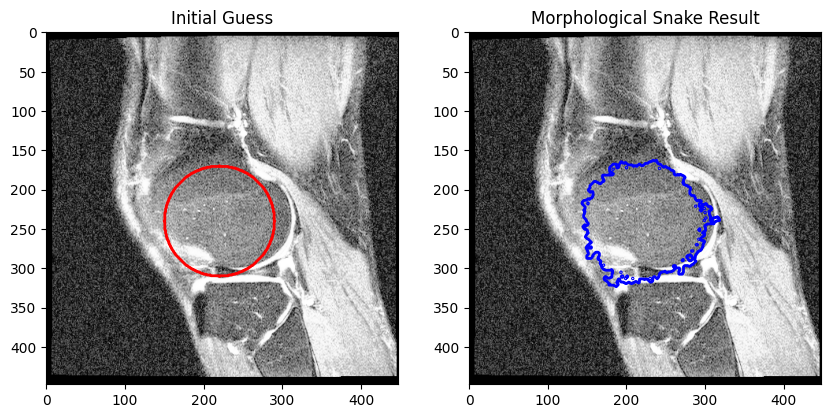

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray")
ax[0].contour(init_mask, [0.5], colors='r', linewidths=2) # Draw initial mask boundary
ax[0].set_title("Initial Guess")

ax[1].imshow(img, cmap="gray")
ax[1].contour(final_mask, [0.5], colors='b', linewidths=2) # Draw final mask boundary
ax[1].set_title("Morphological Snake Result")

plt.show()